
Solved Successfully
States Explored: 2238
Execution Time: 0.2924 seconds

Final Solution:

['☀', '☀', '🌙', '☀', '🌙', '🌙']
['☀', '🌙', '🌙', '☀', '☀', '🌙']
['🌙', '☀', '☀', '🌙', '🌙', '☀']
['☀', '🌙', '🌙', '☀', '🌙', '☀']
['🌙', '☀', '☀', '🌙', '☀', '🌙']
['🌙', '🌙', '☀', '🌙', '☀', '☀']


C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


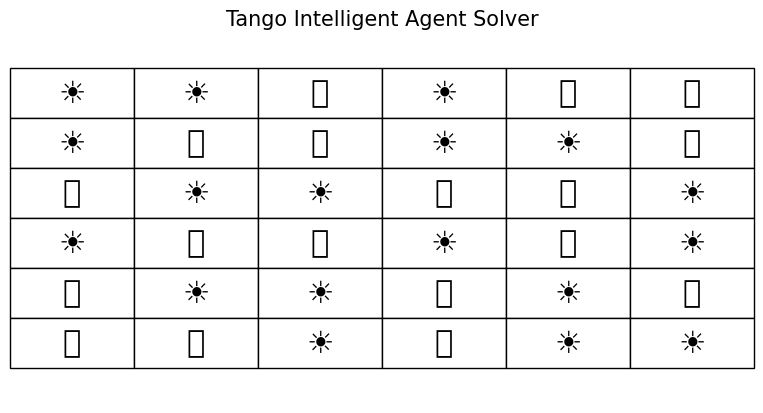

In [3]:
import copy
import heapq
import time
import matplotlib.pyplot as plt

# SYMBOLS
EMPTY = '_'
SUN = 'S'
MOON = 'M'


#INITIAL TANGO PUZZLE
initial_grid = [

    [SUN, EMPTY, EMPTY, EMPTY, MOON, EMPTY],
    [EMPTY, EMPTY, MOON, EMPTY, EMPTY, EMPTY],
    [EMPTY, SUN, EMPTY, EMPTY, EMPTY, EMPTY],
    [EMPTY, EMPTY, EMPTY, SUN, EMPTY, EMPTY],
    [EMPTY, EMPTY, EMPTY, EMPTY, EMPTY, MOON],
    [MOON, EMPTY, EMPTY, EMPTY, EMPTY, EMPTY]

]

# initial_grid = [

#     ['S','S','S','_','M','_'],
#     ['_','_','M','_','_','_'],
#     ['_','S','_','_','_','_'],
#     ['_','_','_','S','_','_'],
#     ['_','_','_','_','_','M'],
#     ['M','_','_','_','_','_']

# ]

# VALIDITY CHECK
def is_valid(grid):

    n = len(grid)

    
    # Equal symbol counting
    for row in grid:

        if row.count(SUN) > n//2:
            return False

        if row.count(MOON) > n//2:
            return False
            
    for c in range(n):

        column = [grid[r][c] for r in range(n)]

        if column.count(SUN) > n//2:
            return False

        if column.count(MOON) > n//2:
            return False

    # No 3 identical together
    for r in range(n):

        for c in range(n-2):

            if grid[r][c] != EMPTY:

                if grid[r][c] == grid[r][c+1] == grid[r][c+2]:
                    return False


    for c in range(n):

        for r in range(n-2):

            if grid[r][c] != EMPTY:

                if grid[r][c] == grid[r+1][c] == grid[r+2][c]:
                    return False


    return True


# HEURISTIC
# h(n)=number of empty cells
def heuristic(grid):
    count = 0
    for row in grid:
        count += row.count(EMPTY)
    return count


# GOAL TEST
def goal_test(grid):
    for row in grid:
        if EMPTY in row:
            return False
    return is_valid(grid)


# GENERATE NEIGHBORS
def generate_neighbors(grid):

    n = len(grid)

    neighbors=[]

    for r in range(n):

        for c in range(n):

            if grid[r][c] == EMPTY:

                for symbol in [SUN,MOON]:

                    new_grid = copy.deepcopy(grid)

                    new_grid[r][c] = symbol

                    if is_valid(new_grid):

                        neighbors.append(new_grid)

                return neighbors

    return neighbors


# A* SEARCH
def a_star(start_grid):

    start_time=time.time()

    pq=[]

    g=0
    h=heuristic(start_grid)

    counter=0

    heapq.heappush(

        pq,
        (g+h,counter,g,start_grid)

    )

    visited=set()


    while pq:

        f,_,g,current=heapq.heappop(pq)

        state=tuple(tuple(row) for row in current)

        if state in visited:
            continue

        visited.add(state)


        if goal_test(current):

            end_time=time.time()

            print("\nSolved Successfully")
            print("States Explored:",len(visited))
            print(
                "Execution Time:",
                round(end_time-start_time,4),
                "seconds"
            )

            return current


        neighbors=generate_neighbors(current)

        for n in neighbors:

            new_g=g+1
            new_h=heuristic(n)

            counter+=1

            heapq.heappush(

                pq,
                (
                    new_g+new_h,
                    counter,
                    new_g,
                    n
                )
            )


    return None


# DISPLAY SYMBOLS
def convert(cell):

    if cell==SUN:
        return "☀"

    elif cell==MOON:
        return "🌙"

    return "⬜"


# VISUALIZE RESULT
def visualize(grid):

    display=[]

    for row in grid:

        new_row=[]

        for cell in row:

            new_row.append(
                convert(cell)
            )

        display.append(new_row)


    fig,ax=plt.subplots()

    ax.axis('off')

    table=ax.table(

        cellText=display,
        loc='center',
        cellLoc='center'

    )

    table.auto_set_font_size(False)

    table.set_fontsize(22)

    table.scale(1.5,3)


    plt.title(
        "Tango Intelligent Agent Solver",
        fontsize=15
    )

    plt.show()


# MAIN
solution=a_star(initial_grid)

if solution:

    print("\nFinal Solution:\n")

    for row in solution:

        print(
            [convert(x) for x in row]
        )

    visualize(solution)

else:

    print("No solution found")